# Signal Research - Round 1

Exploration of predictive signals for ASH_COATED_OSMIUM and INTARIAN_PEPPER_ROOT.

## setup & data loading

In [14]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'figure.figsize': (14, 5), 'figure.dpi': 120})

In [79]:
# config
DATA_DIR = "../data"
DAY_LEN = 1_000_000
EWMA_SPANS = [500]
CONSTANT_ANCHOR = 10_000  # EWMA seed at the start of each day

# load prices 
prices = pd.concat(
    [pd.read_csv(f, sep=";") for f in sorted(glob.glob(f"{DATA_DIR}/prices_round_1_day_*.csv"))],
    ignore_index=True,
).sort_values(["day", "timestamp"]).reset_index(drop=True)

# load trades
trades = pd.concat(
    [pd.read_csv(f, sep=";").assign(day=int(f.split("day_")[1].split(".")[0]))
     for f in sorted(glob.glob(f"{DATA_DIR}/trades_round_1_day_*.csv"))],
    ignore_index=True,
).sort_values(["day", "timestamp"]).reset_index(drop=True)

# continuous time index 
prices["time"] = (prices["day"] - prices["day"].min()) * DAY_LEN + prices["timestamp"]
trades["time"] = (trades["day"] - trades["day"].min()) * DAY_LEN + trades["timestamp"]

# calculate mid and micro price
prices["mid_price"] = (prices["bid_price_1"] + prices["ask_price_1"]) / 2
prices["micro_price"] = (prices["bid_price_1"] * prices["ask_volume_1"] + prices["ask_price_1"] * prices["bid_volume_1"]) / (prices["bid_volume_1"] + prices["ask_volume_1"])

# EWMA of mid, reset per (product, day) and seeded at CONSTANT_ANCHOR — mirrors
# the live trader (round_1_ash_v1.py), which seeds prev=10_000 on first tick.
# NaN mids (missing BBO) are skipped: prev is held, preventing NaN propagation.
def _ewma_seeded(s: pd.Series, span: int, seed: float) -> pd.Series:
    alpha = 2.0 / (span + 1)
    vals = s.to_numpy(dtype=float)
    out = np.empty_like(vals)
    prev = seed
    for i in range(len(vals)):
        x = vals[i]
        if not np.isnan(x):
            prev = alpha * x + (1 - alpha) * prev
        out[i] = prev
    return pd.Series(out, index=s.index)

g_day = prices.groupby(["product", "day"], sort=False)
for span in EWMA_SPANS:
    prices[f"ewma_{span}"] = g_day["mid_price"].transform(
        lambda s, span=span: _ewma_seeded(s, span, CONSTANT_ANCHOR)
    )

# split by product
osmium_ob = prices[prices["product"] == "ASH_COATED_OSMIUM"].reset_index(drop=True)
osmium_trades = trades[trades["symbol"] == "ASH_COATED_OSMIUM"].reset_index(drop=True)
pepper_ob = prices[prices["product"] == "INTARIAN_PEPPER_ROOT"].reset_index(drop=True)
pepper_trades = trades[trades["symbol"] == "INTARIAN_PEPPER_ROOT"].reset_index(drop=True)

print(f"ASH:    {len(osmium_ob)} prices, {len(osmium_trades)} trades")
print(f"PEPPER: {len(pepper_ob)} prices, {len(pepper_trades)} trades")

ASH:    30000 prices, 1265 trades
PEPPER: 30000 prices, 1011 trades


## orderbook analysis

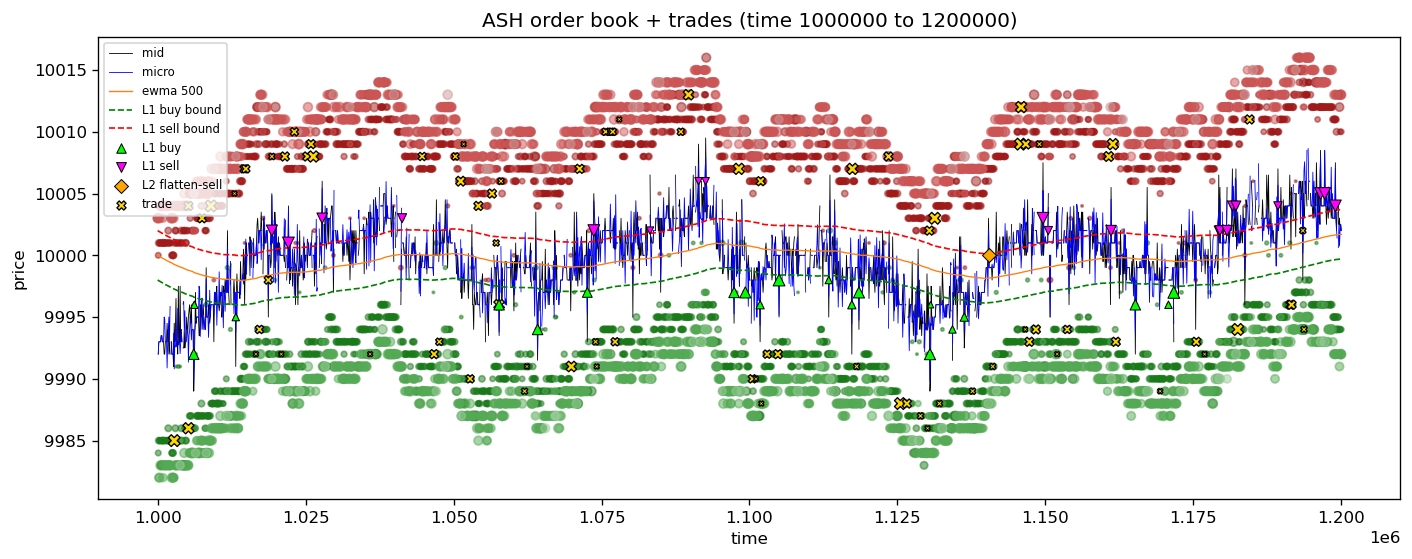

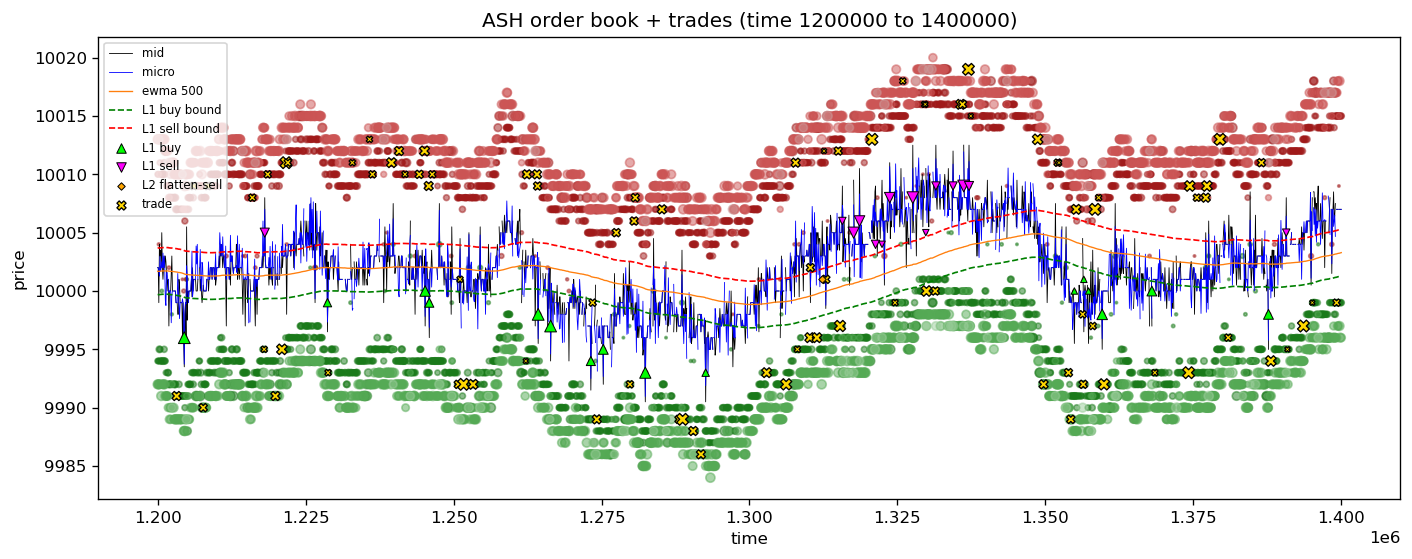

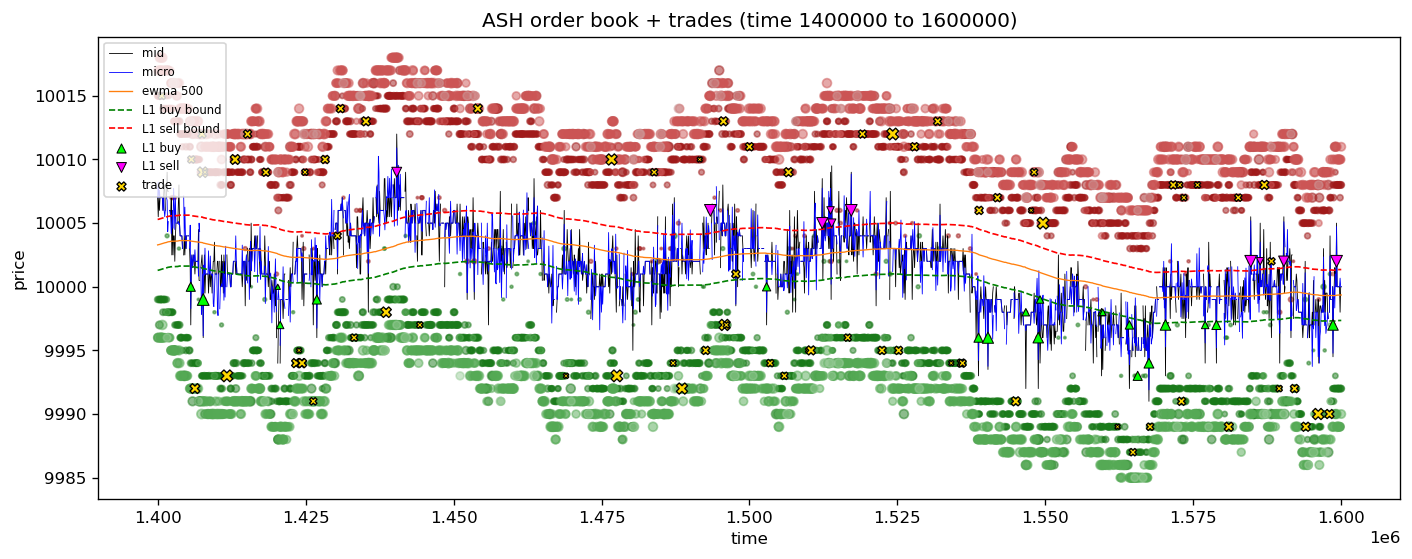

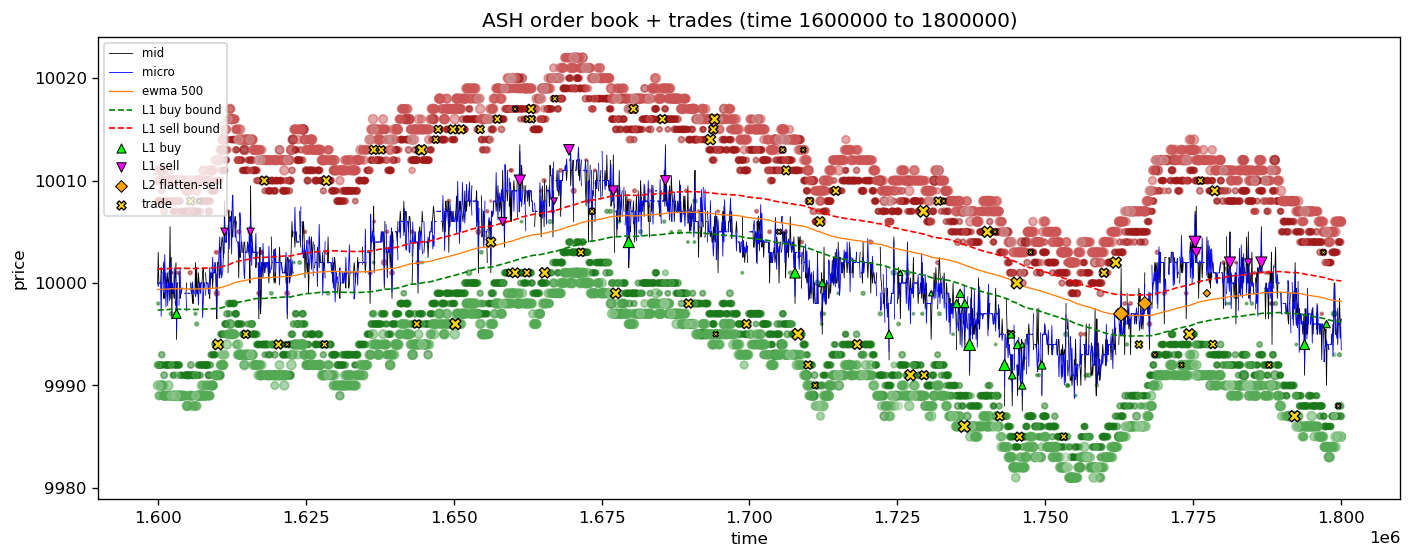

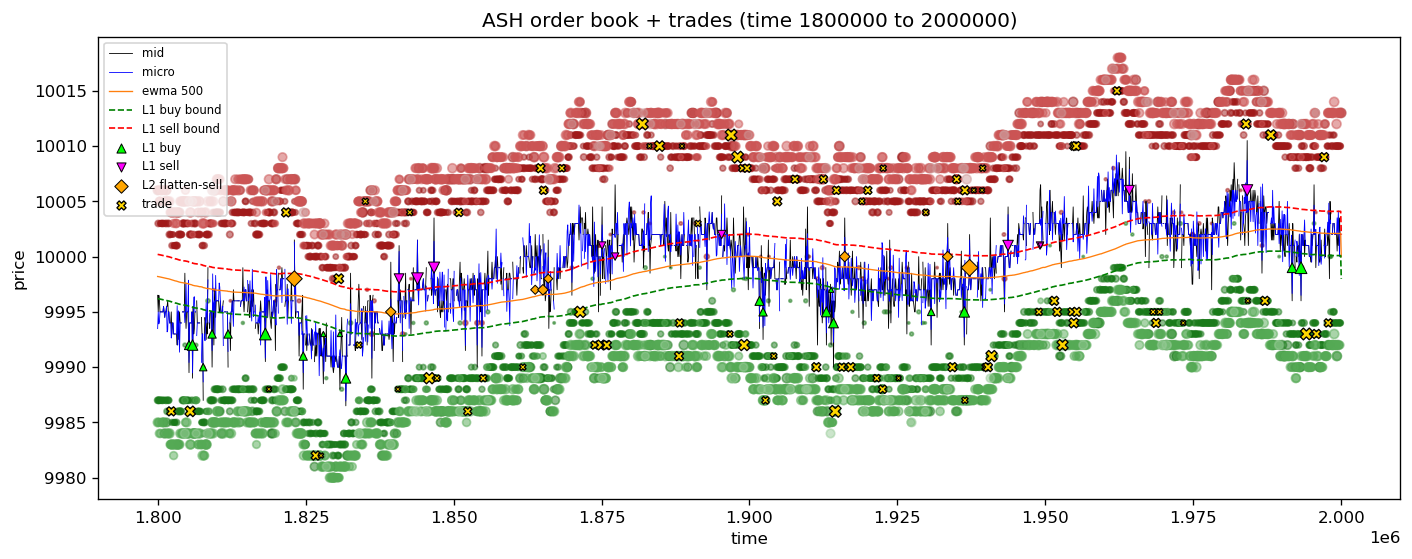

In [80]:
POSITION_LIMIT = 80
FLATTEN_THRESHOLD = 40
FLATTEN_WIDTH = 0

def simulate_takes(df, anchor_col, anchor_width,
                   position_limit=POSITION_LIMIT,
                   layer=2,
                   flatten_threshold=FLATTEN_THRESHOLD,
                   flatten_width=FLATTEN_WIDTH):
    """
    Replay the L1 take + L2 flatten rules tick-by-tick, respecting
    position_limit and book depth. Position resets per day.

    Mirrors round_1_ash_v1.py:
      L1: buy asks <= anchor - anchor_width, sell bids >= anchor + anchor_width
      L2: when |pos| > flatten_threshold, shed down to the threshold at the
          tighter flatten_width bound, using residual book depth after L1.
    """
    fills = []
    for _, g in df.groupby("day", sort=True):
        pos = 0
        for row in g.itertuples(index=False):
            anchor = getattr(row, anchor_col)
            if pd.isna(anchor):
                continue
            lower = anchor - anchor_width
            upper = anchor + anchor_width
            buy_room = position_limit - pos
            sell_room = position_limit + pos

            # Per-level residual volumes so L2 sees post-L1 depth.
            asks = []  # list of [price, remaining_vol]
            bids = []
            for lvl in (1, 2, 3):
                ap = getattr(row, f"ask_price_{lvl}")
                av = getattr(row, f"ask_volume_{lvl}")
                if not (pd.isna(ap) or pd.isna(av)):
                    asks.append([ap, int(av)])
                bp = getattr(row, f"bid_price_{lvl}")
                bv = getattr(row, f"bid_volume_{lvl}")
                if not (pd.isna(bp) or pd.isna(bv)):
                    bids.append([bp, int(bv)])
            asks.sort(key=lambda x: x[0])
            bids.sort(key=lambda x: -x[0])

            # ---------- L1: aggressive takes ----------
            for entry in asks:
                if buy_room <= 0:
                    break
                ap, av = entry
                if ap > lower:
                    break
                qty = min(av, buy_room)
                if qty > 0:
                    pos += qty
                    buy_room -= qty
                    sell_room += qty
                    entry[1] -= qty
                    fills.append((row.time, ap, qty, "buy", 1, pos))

            for entry in bids:
                if sell_room <= 0:
                    break
                bp, bv = entry
                if bp < upper:
                    break
                qty = min(bv, sell_room)
                if qty > 0:
                    pos -= qty
                    sell_room -= qty
                    buy_room += qty
                    entry[1] -= qty
                    fills.append((row.time, bp, -qty, "sell", 1, pos))

            # ---------- L2: flatten when |pos| > flatten_threshold ----------
            if layer >= 2:
                flatten_sell_floor = anchor + flatten_width
                flatten_buy_ceil = anchor - flatten_width

                if pos > flatten_threshold:
                    shed_room = pos - flatten_threshold
                    for entry in bids:
                        if shed_room <= 0 or sell_room <= 0:
                            break
                        bp, bv = entry
                        if bp < flatten_sell_floor:
                            break
                        qty = min(bv, shed_room, sell_room)
                        if qty > 0:
                            pos -= qty
                            sell_room -= qty
                            buy_room += qty
                            shed_room -= qty
                            entry[1] -= qty
                            fills.append((row.time, bp, -qty, "sell", 2, pos))

                elif pos < -flatten_threshold:
                    shed_room = -flatten_threshold - pos
                    for entry in asks:
                        if shed_room <= 0 or buy_room <= 0:
                            break
                        ap, av = entry
                        if ap > flatten_buy_ceil:
                            break
                        qty = min(av, shed_room, buy_room)
                        if qty > 0:
                            pos += qty
                            buy_room -= qty
                            sell_room += qty
                            shed_room -= qty
                            entry[1] -= qty
                            fills.append((row.time, ap, qty, "buy", 2, pos))

    return pd.DataFrame(fills, columns=["time", "price", "qty", "side", "layer", "pos_after"])

def plot_book(df, trades=None, t_start=None, t_end=None, ewma_spans=EWMA_SPANS,
              anchor_col="ewma_5000", anchor_width=2, position_limit=POSITION_LIMIT,
              layer=2, flatten_threshold=FLATTEN_THRESHOLD, flatten_width=FLATTEN_WIDTH,
              ax=None):
    # Simulate on the full df so position state is correct when you zoom in.
    fills = (simulate_takes(df, anchor_col, anchor_width, position_limit,
                            layer=layer,
                            flatten_threshold=flatten_threshold,
                            flatten_width=flatten_width)
             if anchor_col is not None and anchor_col in df.columns else None)

    d = df
    if t_start is not None: d = d[d["time"] >= t_start]
    if t_end is not None:   d = d[d["time"] <= t_end]

    if ax is None:
        _, ax = plt.subplots()

    for side, colors in [("bid", ["#1a7a1a", "#55aa55", "#99cc99"]),
                         ("ask", ["#a01a1a", "#cc5555", "#cc9999"])]:
        for lvl, color in enumerate(colors, start=1):
            p, v = d[f"{side}_price_{lvl}"], d[f"{side}_volume_{lvl}"]
            mask = p.notna() & v.notna()
            ax.scatter(d["time"][mask], p[mask], s=v[mask],
                       c=color, alpha=0.5)
    ax.plot(d["time"], d["mid_price"], color="black", lw=0.5, label="mid")
    ax.plot(d["time"], d["micro_price"], color="blue", lw=0.5, label="micro")

    ewma_colors = ["#ff7f0e", "#9467bd", "#17becf", "#e377c2"]
    for span, color in zip(ewma_spans, ewma_colors):
        col = f"ewma_{span}"
        if col in d.columns:
            ax.plot(d["time"], d[col], color=color, lw=0.8, label=f"ewma {span}")

    # Anchor bounds + position-respecting simulated fills.
    if anchor_col is not None and anchor_col in d.columns:
        anchor = d[anchor_col]
        ax.plot(d["time"], anchor - anchor_width, color="green", lw=1.0, ls="--",
                label="L1 buy bound")
        ax.plot(d["time"], anchor + anchor_width, color="red", lw=1.0, ls="--",
                label="L1 sell bound")
        # if layer >= 2:
        #     ax.plot(d["time"], anchor - flatten_width, color="green", lw=0.8, ls=":",
        #             label="L2 buy bound")
        #     ax.plot(d["time"], anchor + flatten_width, color="red", lw=0.8, ls=":",
        #             label="L2 sell bound")

        if fills is not None and len(fills):
            f = fills
            if t_start is not None: f = f[f["time"] >= t_start]
            if t_end is not None:   f = f[f["time"] <= t_end]
            l1 = f[f["layer"] == 1]
            l2 = f[f["layer"] == 2]
            l1_buys  = l1[l1["side"] == "buy"]
            l1_sells = l1[l1["side"] == "sell"]
            l2_buys  = l2[l2["side"] == "buy"]
            l2_sells = l2[l2["side"] == "sell"]

            if len(l1_buys):
                ax.scatter(l1_buys["time"], l1_buys["price"], s=l1_buys["qty"].abs() * 5,
                           marker="^", c="lime", edgecolors="black", linewidths=0.6,
                           zorder=6, label="L1 buy")
            if len(l1_sells):
                ax.scatter(l1_sells["time"], l1_sells["price"], s=l1_sells["qty"].abs() * 5,
                           marker="v", c="magenta", edgecolors="black", linewidths=0.6,
                           zorder=6, label="L1 sell")
            if len(l2_buys):
                ax.scatter(l2_buys["time"], l2_buys["price"], s=l2_buys["qty"].abs() * 5,
                           marker="D", c="cyan", edgecolors="black", linewidths=0.6,
                           zorder=7, label="L2 flatten-buy")
            if len(l2_sells):
                ax.scatter(l2_sells["time"], l2_sells["price"], s=l2_sells["qty"].abs() * 5,
                           marker="D", c="orange", edgecolors="black", linewidths=0.6,
                           zorder=7, label="L2 flatten-sell")

    if trades is not None:
        t = trades
        if t_start is not None: t = t[t["time"] >= t_start]
        if t_end is not None:   t = t[t["time"] <= t_end]
        ax.scatter(t["time"], t["price"], s=t["quantity"] * 5,
                   marker="X", c="gold", edgecolors="black",
                   linewidths=0.8, label="trade", zorder=5)

    ax.set_xlabel("time"); ax.set_ylabel("price")
    ax.legend(fontsize=7, loc="upper left")
    return ax

RESULTS_DIR = "../results/ash_orderbook"
os.makedirs(RESULTS_DIR, exist_ok=True)

for t_start in range(1_000_000, 2_000_000, 200_000):
     t_end = t_start + 200_000
     plot_book(osmium_ob, trades=osmium_trades, t_start=t_start, t_end=t_end,
               anchor_col="ewma_500", anchor_width=2,
               layer=2, flatten_threshold=FLATTEN_THRESHOLD, flatten_width=FLATTEN_WIDTH)
     plt.title(f"ASH order book + trades (time {t_start} to {t_end})")
     # plt.savefig(f"{RESULTS_DIR}/ash_ob_{t_start:08d}_{t_end:08d}.png", bbox_inches="tight")
     plt.show()
     plt.close()

## imbalance analysis

ASH — L1 imbalance analysis

[1] Imbalance distribution
count    27644.0000
mean        -0.0016
std          0.2335
min         -0.8750
25%          0.0000
50%          0.0000
75%          0.0000
max          0.9091

[2] Correlation with Δmid[t+H]
  H     pearson          p    spearman          p        n
  1     +0.5890   0.00e+00     +0.6233   0.00e+00    25476
  2     +0.5705   0.00e+00     +0.5955   0.00e+00    25488
  5     +0.5537   0.00e+00     +0.5607   0.00e+00    25479
 10     +0.5178   0.00e+00     +0.5109   0.00e+00    25463

[3] OLS Δmid[t+1] ~ α + β·imbalance   (n=25476)
    α = +0.0080
    β = +4.8587   t = +116.34   p = 0.00e+00   R² = 0.3470


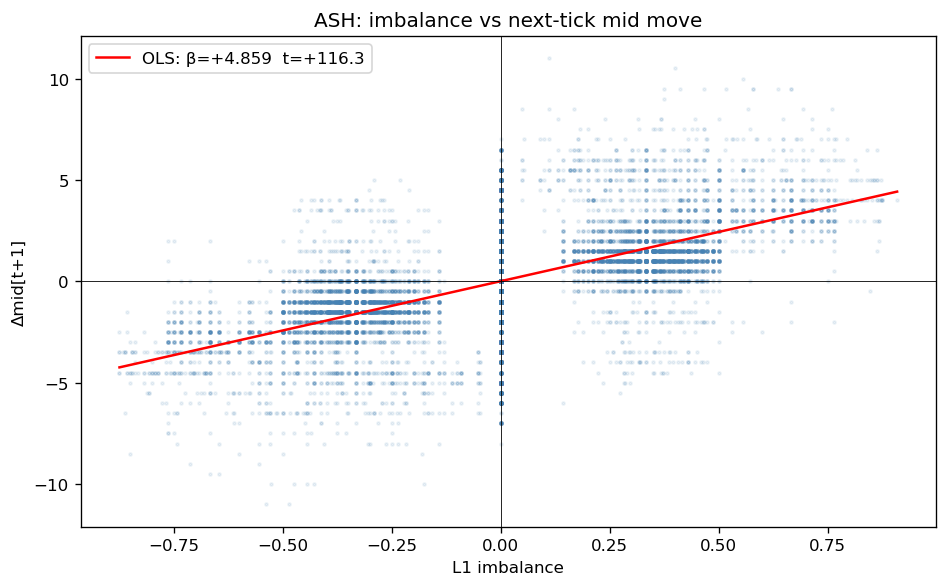


[4] Decile analysis (H=1)
    ANOVA:            F = 3512.71,  p = 0.00e+00
    Kruskal-Wallis:   H = 8394.91,  p = 0.00e+00
                mean     std  count     sem
-0.88..-0.33 -2.0304  1.8053   2680  0.0349
-0.33..+0.00 -0.1466  1.5058  18557  0.0111
+0.00..+0.33  1.6323  1.8880   1935  0.0429
+0.33..+0.91  2.1994  2.0175   2304  0.0420


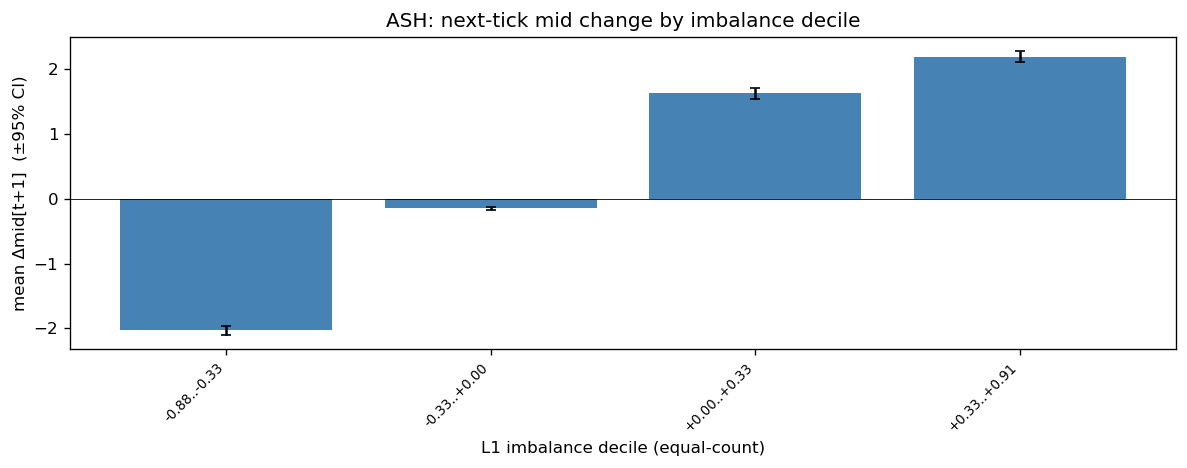

In [45]:
def imbalance_analysis(df, name, horizons=(1, 2, 5, 10), n_bins=10):
    d = df.copy()
    d["imbalance"] = (d["bid_volume_1"] - d["ask_volume_1"]) / (d["bid_volume_1"] + d["ask_volume_1"])

    print("="*60)
    print(f"{name} — L1 imbalance analysis")
    print("="*60)

    # 1. Imbalance summary stats
    print("\n[1] Imbalance distribution")
    print(d["imbalance"].describe().round(4).to_string())

    # 2. Correlation with Δmid[t+H] for each horizon
    print("\n[2] Correlation with Δmid[t+H]")
    print(f"{'H':>3}  {'pearson':>10} {'p':>10}  {'spearman':>10} {'p':>10}  {'n':>7}")
    for H in horizons:
        move = d["mid_price"].shift(-H) - d["mid_price"]
        pair = pd.concat([d["imbalance"], move], axis=1, keys=["x", "y"]).dropna()
        x, y = pair["x"].values, pair["y"].values
        r_p, p_p = stats.pearsonr(x, y)
        r_s, p_s = stats.spearmanr(x, y)
        print(f"{H:>3}  {r_p:+10.4f} {p_p:>10.2e}  {r_s:+10.4f} {p_s:>10.2e}  {len(pair):>7}")

    # 3. OLS regression at H=1 + scatter
    move1 = d["mid_price"].shift(-1) - d["mid_price"]
    pair = pd.concat([d["imbalance"], move1], axis=1, keys=["x", "y"]).dropna()
    x, y = pair["x"].values, pair["y"].values
    slope, intercept, r, p_ols, se = stats.linregress(x, y)
    tstat = slope / se
    print(f"\n[3] OLS Δmid[t+1] ~ α + β·imbalance   (n={len(pair)})")
    print(f"    α = {intercept:+.4f}")
    print(f"    β = {slope:+.4f}   t = {tstat:+.2f}   p = {p_ols:.2e}   R² = {r**2:.4f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(x, y, s=3, alpha=0.1, color="steelblue")
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, intercept + slope * xs, color="red", lw=1.5,
            label=f"OLS: β={slope:+.3f}  t={tstat:+.1f}")
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(0, color="black", lw=0.5)
    ax.set_xlabel("L1 imbalance")
    ax.set_ylabel("Δmid[t+1]")
    ax.set_title(f"{name}: imbalance vs next-tick mid move")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # 4. Decile analysis at H=1 with ANOVA / Kruskal-Wallis
    deciles = pd.qcut(pair["x"], q=n_bins, duplicates="drop")
    groups = [pair["y"][deciles == lvl].values for lvl in deciles.cat.categories]
    f_stat, p_anova = stats.f_oneway(*groups)
    h_stat, p_kw = stats.kruskal(*groups)

    grouped = pair["y"].groupby(deciles, observed=True).agg(["mean", "std", "count"])
    grouped["sem"] = grouped["std"] / np.sqrt(grouped["count"])
    grouped.index = [f"{iv.left:+.2f}..{iv.right:+.2f}" for iv in grouped.index]

    print(f"\n[4] Decile analysis (H=1)")
    print(f"    ANOVA:            F = {f_stat:.2f},  p = {p_anova:.2e}")
    print(f"    Kruskal-Wallis:   H = {h_stat:.2f},  p = {p_kw:.2e}")
    print(grouped.round(4).to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(grouped)), grouped["mean"], yerr=1.96 * grouped["sem"],
           color="steelblue", capsize=3)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels(grouped.index, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("L1 imbalance decile (equal-count)")
    ax.set_ylabel("mean Δmid[t+1]  (±95% CI)")
    ax.set_title(f"{name}: next-tick mid change by imbalance decile")
    plt.tight_layout()
    plt.show()

imbalance_analysis(osmium_ob, "ASH")

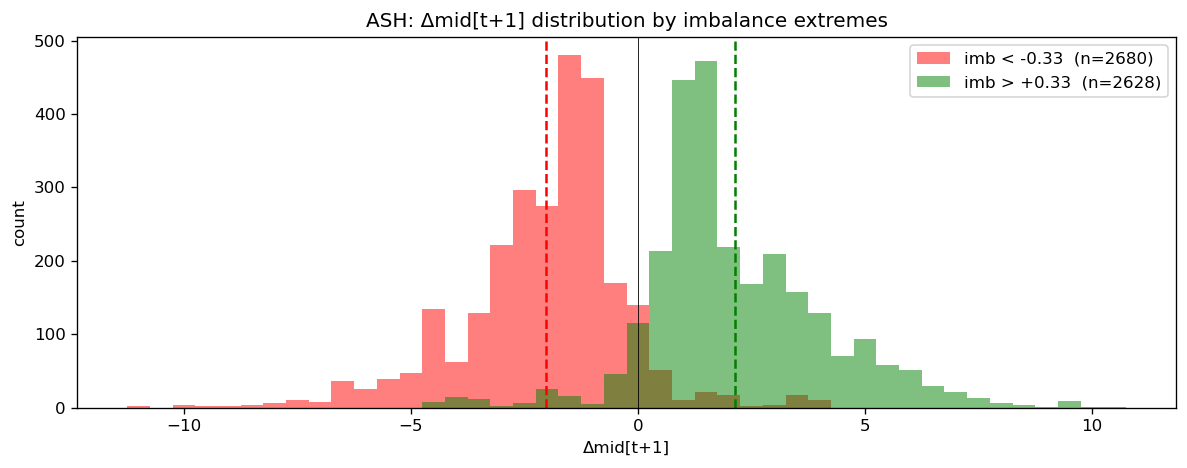

In [63]:
d = osmium_ob.copy()
d["imbalance"] = (d["bid_volume_1"] - d["ask_volume_1"]) / (d["bid_volume_1"] + d["ask_volume_1"])
d["dmid1"] = d["mid_price"].shift(-1) - d["mid_price"]

low  = d.loc[d["imbalance"] < -0.33, "dmid1"].dropna()
high = d.loc[d["imbalance"] >  0.33, "dmid1"].dropna()

bins = np.arange(min(low.min(), high.min()) - 0.25, max(low.max(), high.max()) + 0.75, 0.5)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(low,  bins=bins, alpha=0.5, color="red",   label=f"imb < -0.33  (n={len(low)})")
ax.hist(high, bins=bins, alpha=0.5, color="green", label=f"imb > +0.33  (n={len(high)})")
ax.axvline(low.mean(),  color="red",   lw=1.5, ls="--")
ax.axvline(high.mean(), color="green", lw=1.5, ls="--")
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Δmid[t+1]")
ax.set_ylabel("count")
ax.set_title("ASH: Δmid[t+1] distribution by imbalance extremes")
ax.legend()
plt.tight_layout()
plt.show()

## boundary analysis

ASH — mid price boundary analysis

[1] Mid price distribution
count    27644.0000
mean     10000.2091
std          4.8582
min       9981.5000
25%       9997.0000
50%      10000.5000
75%      10003.0000
max      10017.5000

[2] Tail probabilities for [9990, 10010]
    P(mid < 9990)           =   1.508%   (n = 417)
    P(mid > 10010)          =   1.859%   (n = 514)
    P(9990 ≤ mid ≤ 10010)   =  96.632%   (n = 26713)
    quantiles:
      q=  0.10%:   9986.00
      q=  1.00%:   9989.00
      q=  5.00%:   9992.00
      q= 50.00%:   10000.50
      q= 95.00%:   10008.00
      q= 99.00%:   10012.00
      q= 99.90%:   10015.00

[3] Confidence interval on P(mid outside [9990, 10010])
    p̂ = 3.368%   (n_out = 931, n_total = 27644)
    95% Clopper-Pearson CI:  [3.1583%, 3.5872%]


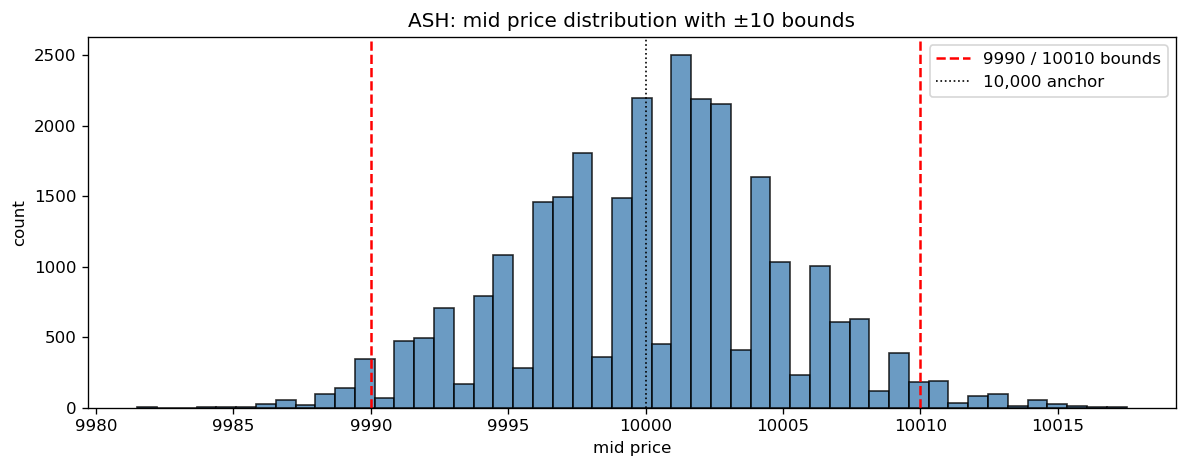

In [70]:
def boundary_analysis(df, name, lo=9990, hi=10010):
    m = df["mid_price"].dropna()

    print("="*60)
    print(f"{name} — mid price boundary analysis")
    print("="*60)

    # 1. Summary stats
    print("\n[1] Mid price distribution")
    print(m.describe().round(4).to_string())

    # 2. Tail probabilities
    print(f"\n[2] Tail probabilities for [{lo}, {hi}]")
    n_below = int((m < lo).sum())
    n_above = int((m > hi).sum())
    n_inside = int(((m >= lo) & (m <= hi)).sum())
    print(f"    P(mid < {lo})           = {n_below/len(m)*100:>7.3f}%   (n = {n_below})")
    print(f"    P(mid > {hi})          = {n_above/len(m)*100:>7.3f}%   (n = {n_above})")
    print(f"    P({lo} ≤ mid ≤ {hi})   = {n_inside/len(m)*100:>7.3f}%   (n = {n_inside})")
    print(f"    quantiles:")
    for q in [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]:
        print(f"      q={q*100:>6.2f}%:   {m.quantile(q):.2f}")

    # 3. Clopper-Pearson 95% CI on P(outside bounds)
    n_out = n_below + n_above
    p_hat = n_out / len(m)
    ci_lo = stats.beta.ppf(0.025, n_out, len(m) - n_out + 1) if n_out > 0 else 0.0
    ci_hi = stats.beta.ppf(0.975, n_out + 1, len(m) - n_out)
    print(f"\n[3] Confidence interval on P(mid outside [{lo}, {hi}])")
    print(f"    p̂ = {p_hat*100:.3f}%   (n_out = {n_out}, n_total = {len(m)})")
    print(f"    95% Clopper-Pearson CI:  [{ci_lo*100:.4f}%, {ci_hi*100:.4f}%]")

    # 4. Distribution plot
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(m, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
    ax.axvline(lo, color="red", lw=1.5, ls="--", label=f"{lo} / {hi} bounds")
    ax.axvline(hi, color="red", lw=1.5, ls="--")
    ax.axvline(10_000, color="black", lw=1, ls=":", label="10,000 anchor")
    ax.set_xlabel("mid price")
    ax.set_ylabel("count")
    ax.set_title(f"{name}: mid price distribution with ±10 bounds")
    ax.legend()
    plt.tight_layout()
    plt.show()

boundary_analysis(osmium_ob, "ASH", lo=9990, hi=10010)

## pepper analysis

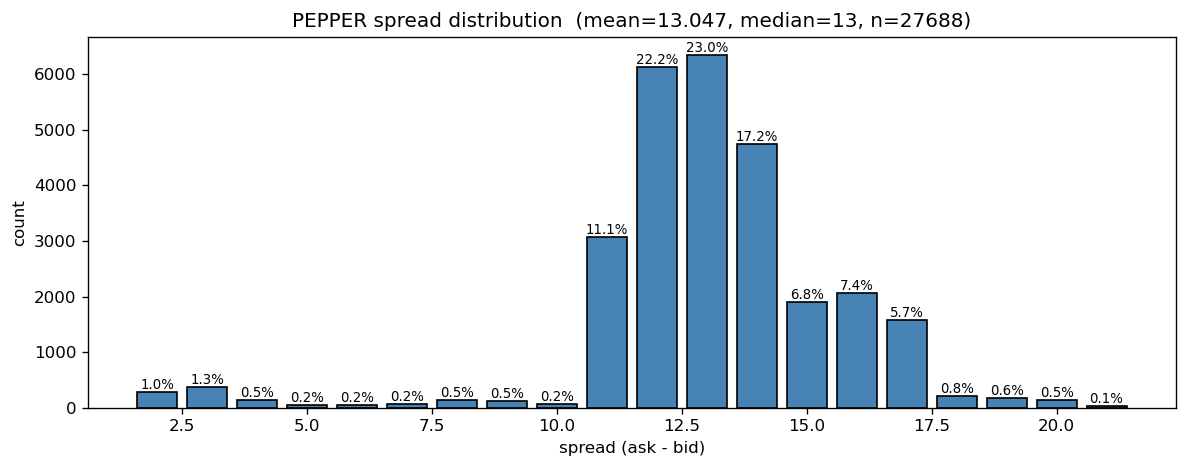

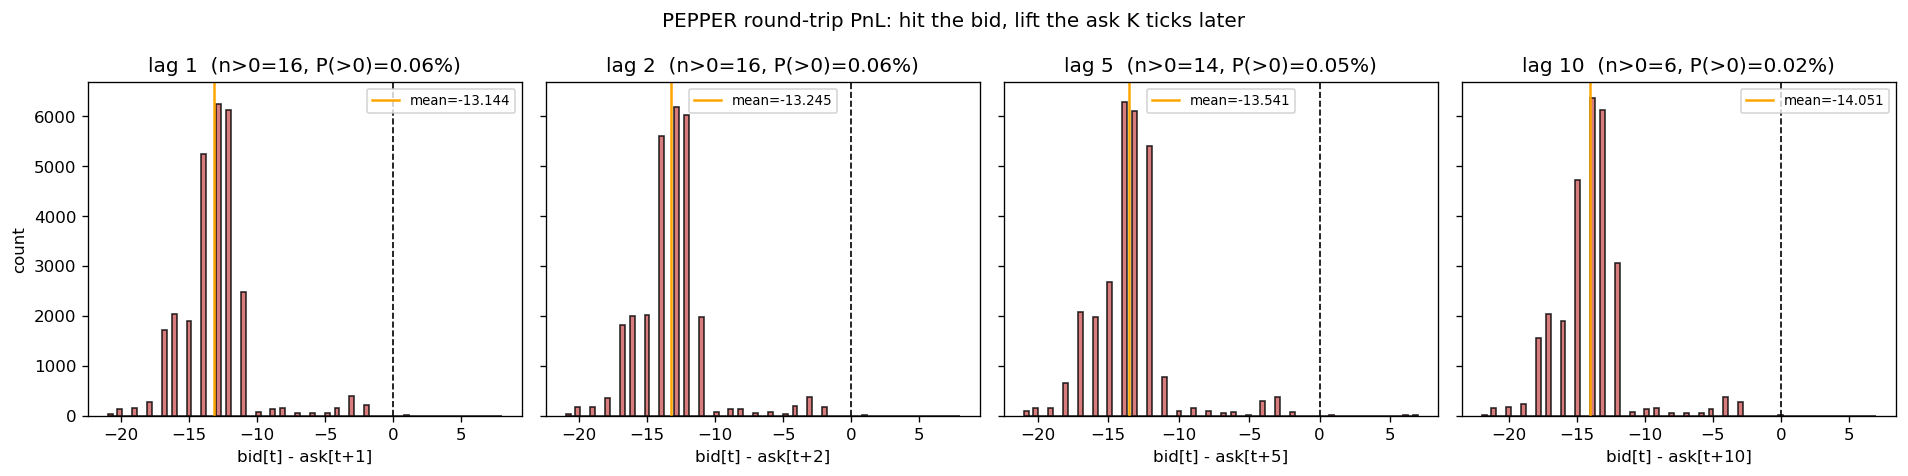


PEPPER round-trip PnL summary
 lag      mean    median       std       n>0    P(>0)%       max         n
   1   -13.144     -13.0     2.634        16      0.06      +8.0     27681
   2   -13.245     -13.0     2.639        16      0.06      +8.0     27672
   5   -13.541     -14.0     2.640        14      0.05      +7.0     27658
  10   -14.051     -14.0     2.637         6      0.02      +7.0     27657


In [75]:
LAGS = [1, 2, 5, 10]

d = pepper_ob.copy()
d["spread"] = d["ask_price_1"] - d["bid_price_1"]

# Shift within-day so we don't bleed across day boundaries.
g = d.groupby("day", sort=True)
for k in LAGS:
    d[f"mid_delta_{k}"] = g["mid_price"].shift(-k) - d["mid_price"]
    # Round-trip: sell at bid[t] (hit the bid), buy back at ask[t+k] (lift the ask).
    d[f"rt_pnl_{k}"] = d["bid_price_1"] - g["ask_price_1"].shift(-k)

# 1) spread distribution
s = d["spread"].dropna()
counts = s.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts.index, counts.values, color="steelblue", edgecolor="black")
for x, y in zip(counts.index, counts.values):
    ax.text(x, y, f"{y/len(s)*100:.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("spread (ask - bid)")
ax.set_ylabel("count")
ax.set_title(f"PEPPER spread distribution  (mean={s.mean():.3f}, median={s.median():.0f}, n={len(s)})")
plt.tight_layout()
plt.show()

# 2) round-trip PnL: sell at bid[t], buy back at ask[t+k]
fig, axes = plt.subplots(1, len(LAGS), figsize=(4 * len(LAGS), 4), sharey=True)
for k, ax in zip(LAGS, axes):
    x = d[f"rt_pnl_{k}"].dropna()
    n_pos = int((x > 0).sum())
    frac_pos = n_pos / len(x) * 100
    ax.hist(x, bins=80, color="indianred", edgecolor="black", alpha=0.8)
    ax.axvline(0, color="black", lw=1, ls="--")
    ax.axvline(x.mean(), color="orange", lw=1.5, label=f"mean={x.mean():+.3f}")
    ax.set_xlabel(f"bid[t] - ask[t+{k}]")
    ax.set_title(f"lag {k}  (n>0={n_pos}, P(>0)={frac_pos:.2f}%)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
plt.suptitle("PEPPER round-trip PnL: hit the bid, lift the ask K ticks later")
plt.tight_layout()
plt.show()

# Summary table
print("\nPEPPER round-trip PnL summary")
print(f"{'lag':>4}  {'mean':>8}  {'median':>8}  {'std':>8}  {'n>0':>8}  {'P(>0)%':>8}  {'max':>8}  {'n':>8}")
for k in LAGS:
    x = d[f"rt_pnl_{k}"].dropna()
    n_pos = int((x > 0).sum())
    print(f"{k:>4}  {x.mean():>+8.3f}  {x.median():>+8.1f}  {x.std():>8.3f}  "
          f"{n_pos:>8}  {n_pos / len(x) * 100:>8.2f}  {x.max():>+8.1f}  {len(x):>8}")

In [68]:
# Exact timestamps where round-trip PnL > 0, per lag.
# Uses `d` from the cell above (pepper_ob with rt_pnl_{k} columns).
for k in LAGS:
    col = f"rt_pnl_{k}"
    hits = d.loc[d[col] > 0, ["day", "timestamp", "time", "bid_price_1", col]].copy()
    hits[f"ask[t+{k}]"] = hits["bid_price_1"] - hits[col]
    hits = hits.rename(columns={"bid_price_1": "bid[t]", col: "pnl"})
    hits = hits[["day", "timestamp", "time", "bid[t]", f"ask[t+{k}]", "pnl"]]
    print(f"\nlag {k}: {len(hits)} positive round-trips")
    if len(hits):
        print(hits.to_string(index=False))


lag 1: 16 positive round-trips
 day  timestamp    time  bid[t]  ask[t+1]  pnl
  -2     298200  298200 10301.0   10295.0  6.0
  -2     363300  363300 10366.0   10365.0  1.0
  -2     489500  489500 10487.0   10486.0  1.0
  -2     545300  545300 10543.0   10542.0  1.0
  -2     572800  572800 10575.0   10569.0  6.0
  -2     757600  757600 10760.0   10759.0  1.0
  -1     390300 1390300 11393.0   11392.0  1.0
  -1     435500 1435500 11438.0   11432.0  6.0
  -1     454400 1454400 11457.0   11456.0  1.0
  -1     543300 1543300 11546.0   11545.0  1.0
  -1     550200 1550200 11553.0   11546.0  7.0
  -1     814900 1814900 11812.0   11811.0  1.0
  -1     847300 1847300 11844.0   11843.0  1.0
  -1     936200 1936200 11939.0   11938.0  1.0
   0     256100 2256100 12259.0   12258.0  1.0
   0     346300 2346300 12350.0   12342.0  8.0

lag 2: 16 positive round-trips
 day  timestamp    time  bid[t]  ask[t+2]  pnl
  -2     136800  136800 10139.0   10133.0  6.0
  -2     423100  423100 10421.0   10420.0  

lag 10: 6 positive round-trips  (plotting up to 20)


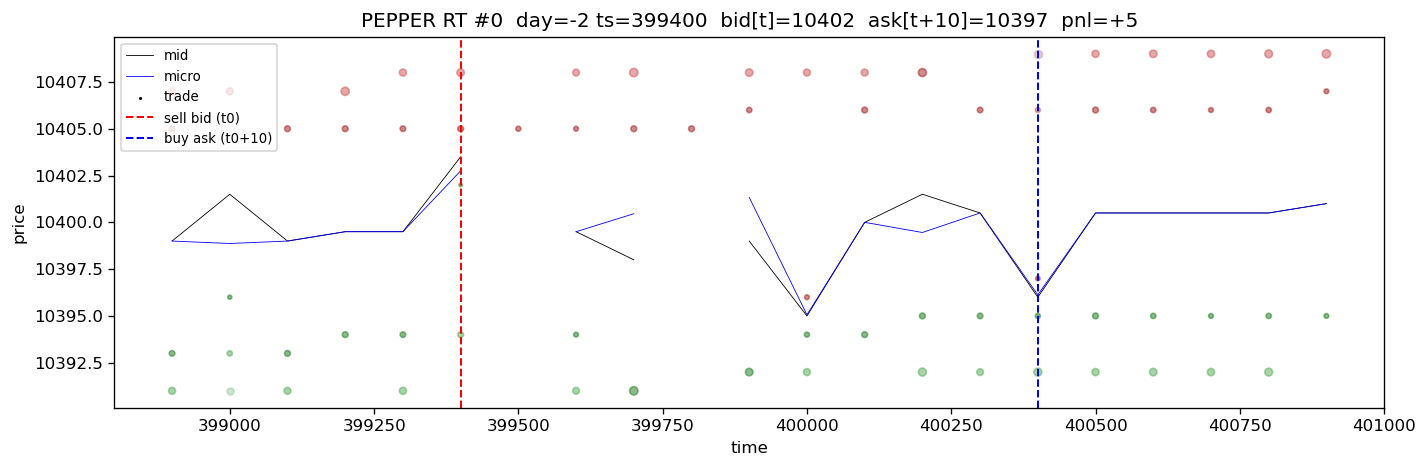

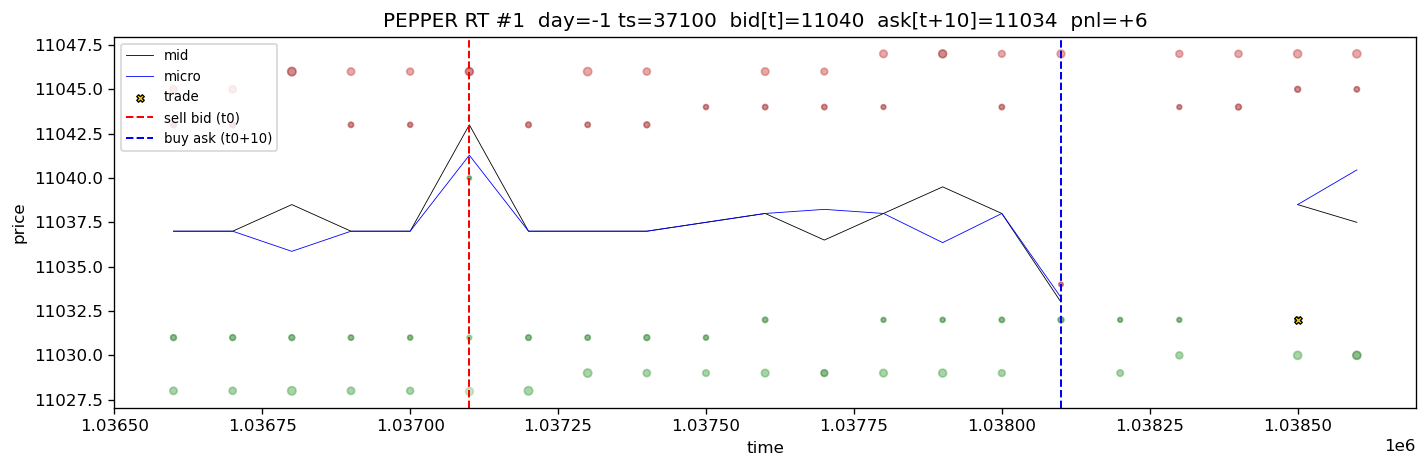

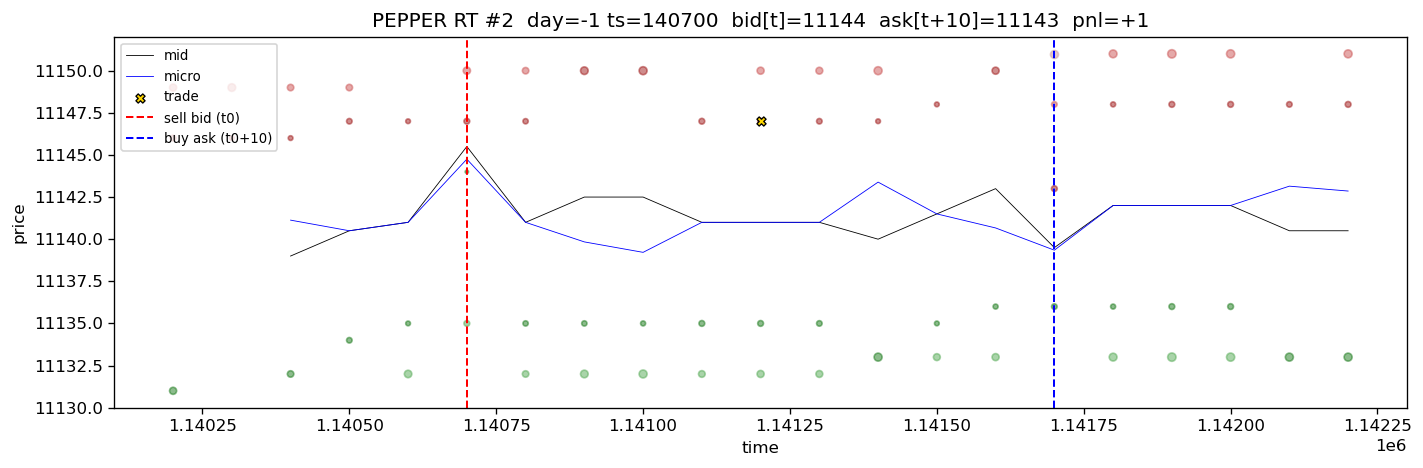

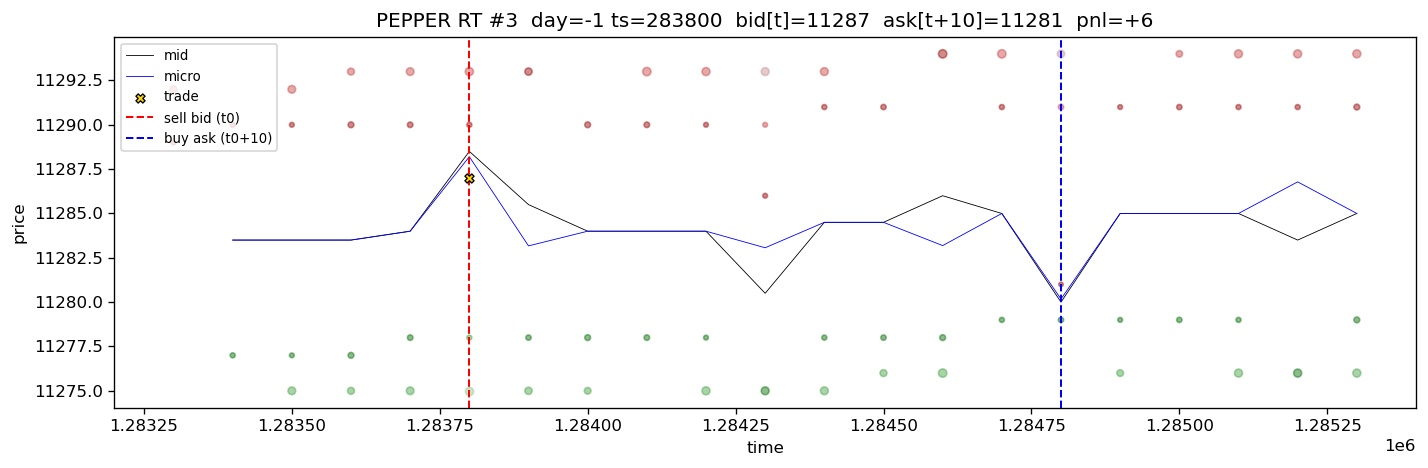

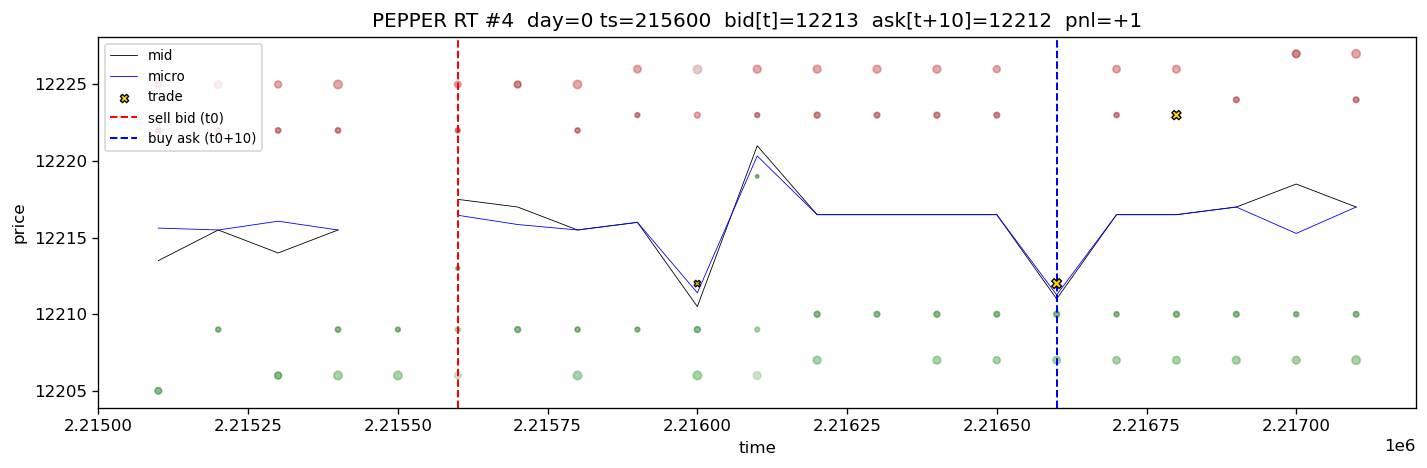

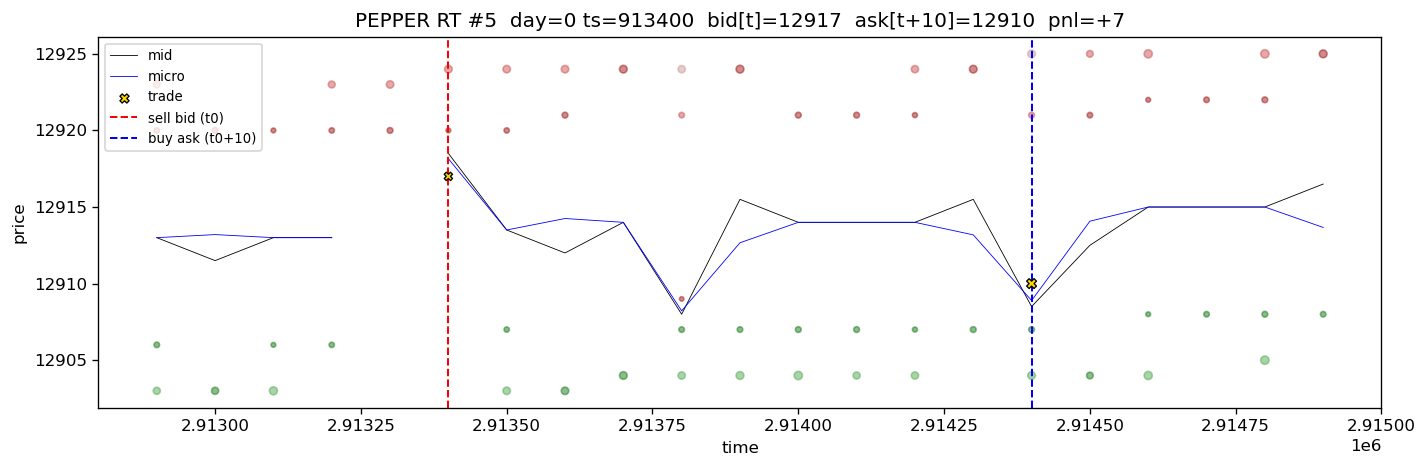

In [74]:
# Plot pepper orderbook + trades around each positive round-trip instance.
# Reuses `plot_book` but passes anchor_col=None so no anchor/L1/L2 overlay is drawn.
LAG = 10             # which rt_pnl_{k} column to inspect
WINDOW_TICKS = 5     # ticks before and after the trigger timestamp to plot
MAX_PLOTS = 20       # cap to keep rendering tractable
TICK_STEP = 100      # Prosperity timestamp step

col = f"rt_pnl_{LAG}"
hits = d.loc[d[col] > 0].sort_values("time").reset_index(drop=True)
print(f"lag {LAG}: {len(hits)} positive round-trips  (plotting up to {MAX_PLOTS})")

for i, row in hits.head(MAX_PLOTS).iterrows():
    t0 = int(row["time"])
    bid_t = row["bid_price_1"]
    ask_tk = bid_t - row[col]   # ask[t+k] reconstructed from stored PnL

    t_start = t0 - WINDOW_TICKS * TICK_STEP
    t_end = t0 + (WINDOW_TICKS + LAG) * TICK_STEP

    fig, ax = plt.subplots(figsize=(12, 4))
    plot_book(pepper_ob, trades=pepper_trades,
              t_start=t_start, t_end=t_end,
              anchor_col=None, ewma_spans=[],
              ax=ax)
    ax.axvline(t0, color="red", lw=1.2, ls="--", label="sell bid (t0)")
    ax.axvline(t0 + LAG * TICK_STEP, color="blue", lw=1.2, ls="--", label=f"buy ask (t0+{LAG})")
    ax.legend(fontsize=8, loc="upper left")
    ax.set_title(
        f"PEPPER RT #{i}  day={int(row['day'])} ts={int(row['timestamp'])}  "
        f"bid[t]={bid_t:.0f}  ask[t+{LAG}]={ask_tk:.0f}  pnl=+{row[col]:.0f}"
    )
    plt.tight_layout()
    plt.show()
    plt.close()

PEPPER: count of ticks with best_bid >= theo + X
   X    n_bids    % ticks
   0       464      1.55%
   1       464      1.55%
   2       464      1.55%
   3       233      0.78%
   5         0      0.00%
  10         0      0.00%
  20         0      0.00%

Among those ticks — wait time until next ask <= theo (time units; Prosperity tick = 100)
   X         n        mean      median       min         max    %NaN
   0       464        6109        4400       100       33400    0.6%
   1       464        6109        4400       100       33400    0.6%
   2       464        6109        4400       100       33400    0.6%
   3       233        6161        4500       100       29800    0.9%
   5         0         N/A         N/A       N/A         N/A    0.0%
  10         0         N/A         N/A       N/A         N/A    0.0%
  20         0         N/A         N/A       N/A         N/A    0.0%


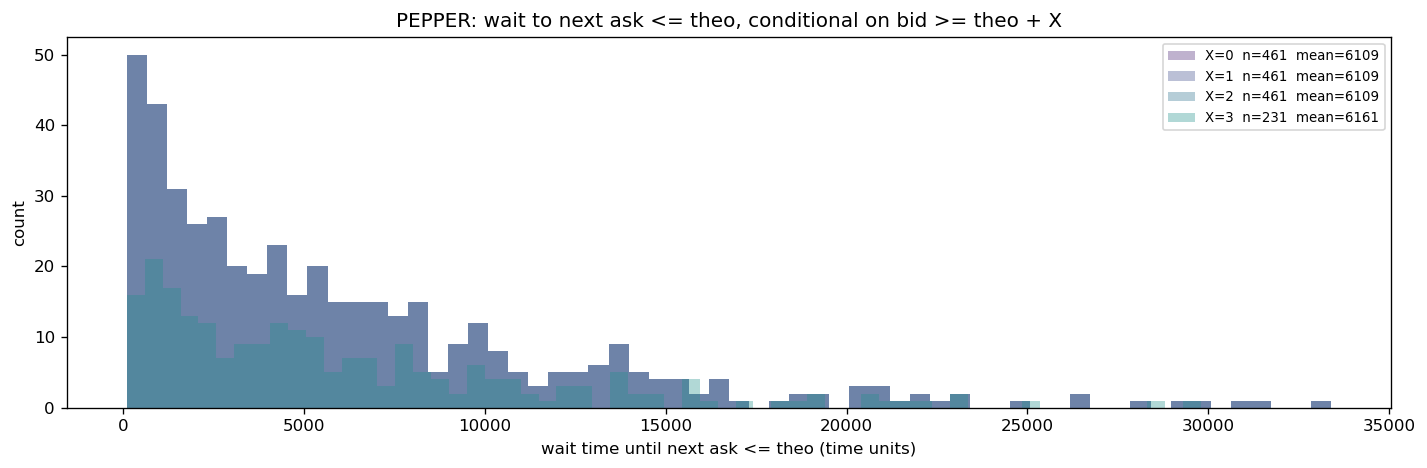

In [78]:
# For each X, count how many ticks have best_bid >= theo + X,
# and measure wait time until the next ask <= theo appears (the buy-back).
# theo = 10_000 + 0.001 * time
XS = [0, 1, 2, 3, 5, 10, 20]

dp = pepper_ob.copy().reset_index(drop=True)
dp["theo"] = 10_000 + 0.001 * dp["time"]
dp["bid_edge"] = dp["bid_price_1"] - dp["theo"]
dp["ask_edge"] = dp["theo"] - dp["ask_price_1"]

# Per-day: wait[i] = time until the next strictly future tick where ask <= theo.
waits = np.full(len(dp), np.nan)
for _, sub in dp.groupby("day", sort=False):
    idx = sub.index.to_numpy()
    times = sub["time"].to_numpy()
    ask_below = (sub["ask_price_1"] <= sub["theo"]).to_numpy()
    next_j = None
    for k in range(len(sub) - 1, -1, -1):
        if next_j is not None:
            waits[idx[k]] = times[next_j] - times[k]
        if ask_below[k]:
            next_j = k
    # Note: the last tick of each day stays NaN (no future ask in-day).

dp["wait_to_ask_below"] = waits

# 1) counts
print("PEPPER: count of ticks with best_bid >= theo + X")
print(f"{'X':>4}  {'n_bids':>8}  {'% ticks':>9}")
for X in XS:
    n = int((dp["bid_edge"] >= X).sum())
    print(f"{X:>4}  {n:>8}  {n/len(dp)*100:>8.2f}%")

# 2) wait stats conditional on bid_edge >= X
print("\nAmong those ticks — wait time until next ask <= theo (time units; Prosperity tick = 100)")
print(f"{'X':>4}  {'n':>8}  {'mean':>10}  {'median':>10}  {'min':>8}  {'max':>10}  {'%NaN':>6}")
for X in XS:
    w = dp.loc[dp["bid_edge"] >= X, "wait_to_ask_below"]
    n = len(w)
    wc = w.dropna()
    nan_pct = w.isna().mean() * 100 if n else 0
    if len(wc):
        print(f"{X:>4}  {n:>8}  {wc.mean():>10.0f}  {wc.median():>10.0f}  "
              f"{wc.min():>8.0f}  {wc.max():>10.0f}  {nan_pct:>5.1f}%")
    else:
        print(f"{X:>4}  {n:>8}  {'N/A':>10}  {'N/A':>10}  {'N/A':>8}  {'N/A':>10}  {nan_pct:>5.1f}%")

# Distribution of wait times per X
fig, ax = plt.subplots(figsize=(12, 4))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(XS)))
for X, c in zip(XS, colors):
    w = dp.loc[dp["bid_edge"] >= X, "wait_to_ask_below"].dropna()
    if len(w) == 0: continue
    ax.hist(w, bins=60, alpha=0.35, color=c,
            label=f"X={X}  n={len(w)}  mean={w.mean():.0f}")
ax.set_xlabel("wait time until next ask <= theo (time units)")
ax.set_ylabel("count")
ax.set_title("PEPPER: wait to next ask <= theo, conditional on bid >= theo + X")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()